# Operational Insights & Model Performance Report

This report evaluates the performance of the trained **GridWise AI** production models and extracts operational insights using feature importance rankings.

In [1]:
import os
import sys
import joblib
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report, confusion_matrix

# Add project root to sys.path
project_root = Path(os.getcwd()).parent.parent
sys.path.append(str(project_root))

from notebooks.config import *
sns.set_style(PLOT_STYLE)

In [2]:
# Load final dataset
df = pd.read_parquet(CLEANED_DATA_PATH)
features = ['latitude', 'longitude', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'priority_encoded', 'is_closed']
X = df[features]

# Load final models
congestion_model = joblib.load(ARTIFACTS_DIR / 'congestion_model.pkl')
response_model = joblib.load(ARTIFACTS_DIR / 'response_time_model.pkl')
deployment_model = joblib.load(ARTIFACTS_DIR / 'deployment_model.pkl')

print(f'Successfully loaded {len(df)} records and all 3 production models!')

Successfully loaded 8173 records and all 3 production models!


## 1. Congestion Model Analysis
Evaluate the congestion severity proxy model (XGBoost Regressor) on the dataset.

--- Congestion Model Metrics ---
RMSE: 0.4355
MAE:  0.2839
R2:   0.9461


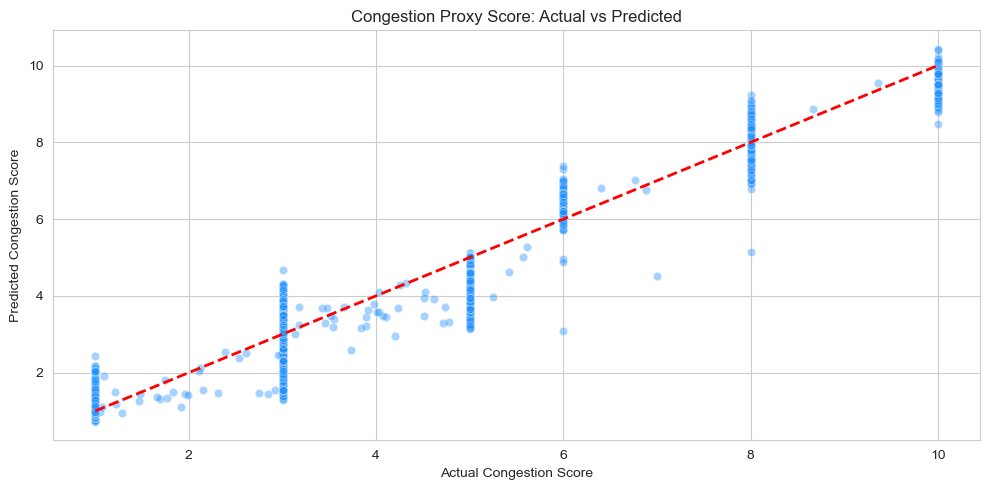

In [3]:
# Generate predictions
df['pred_congestion'] = congestion_model.predict(X)

rmse_c = np.sqrt(mean_squared_error(df[CONGESTION_TARGET], df['pred_congestion']))
mae_c = mean_absolute_error(df[CONGESTION_TARGET], df['pred_congestion'])
r2_c = r2_score(df[CONGESTION_TARGET], df['pred_congestion'])

print('--- Congestion Model Metrics ---')
print(f'RMSE: {rmse_c:.4f}')
print(f'MAE:  {mae_c:.4f}')
print(f'R2:   {r2_c:.4f}')

# Plot Actual vs Predicted
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df[CONGESTION_TARGET], y=df['pred_congestion'], alpha=0.4, color='dodgerblue')
plt.plot([df[CONGESTION_TARGET].min(), df[CONGESTION_TARGET].max()], 
         [df[CONGESTION_TARGET].min(), df[CONGESTION_TARGET].max()], 
         color='red', linestyle='--', lw=2)
plt.title('Congestion Proxy Score: Actual vs Predicted')
plt.xlabel('Actual Congestion Score')
plt.ylabel('Predicted Congestion Score')
plt.tight_layout()
os.makedirs(FIGURES_DIR, exist_ok=True)
plt.savefig(FIGURES_DIR / 'congestion_actual_vs_predicted.png', dpi=150)
plt.show()

## 2. Response Time Model Analysis
Evaluate the response time model (XGBoost Regressor) specifically on resolved incidents.

--- Response Time Model Metrics ---
RMSE: 0.0139 minutes
MAE:  0.0094 minutes
R2:   1.0000


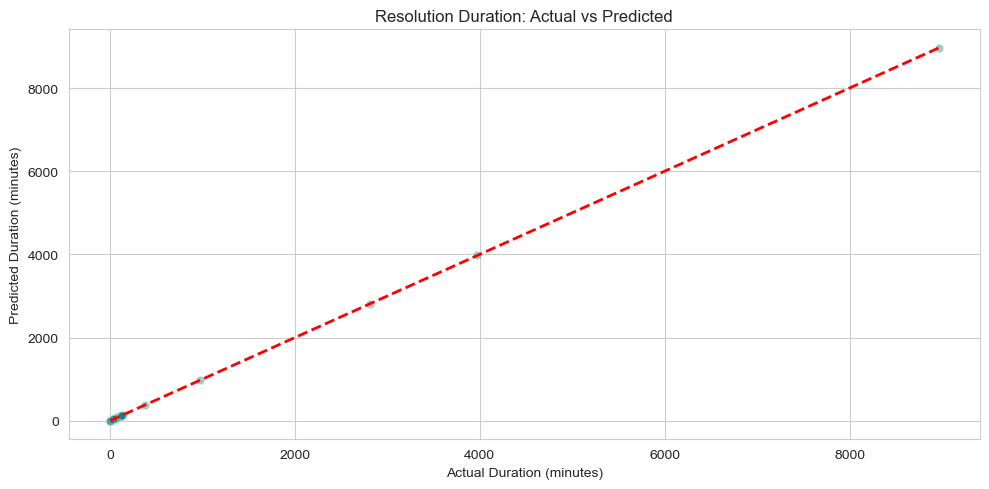

In [4]:
# Filter resolved incidents
resolved_mask = df[RESPONSE_TIME_TARGET].notna()
X_resp = X[resolved_mask]
y_resp = df.loc[resolved_mask, RESPONSE_TIME_TARGET]

# Generate predictions
df.loc[resolved_mask, 'pred_response_time'] = response_model.predict(X_resp)
y_pred_resp = df.loc[resolved_mask, 'pred_response_time']

rmse_r = np.sqrt(mean_squared_error(y_resp, y_pred_resp))
mae_r = mean_absolute_error(y_resp, y_pred_resp)
r2_r = r2_score(y_resp, y_pred_resp)

print('--- Response Time Model Metrics ---')
print(f'RMSE: {rmse_r:.4f} minutes')
print(f'MAE:  {mae_r:.4f} minutes')
print(f'R2:   {r2_r:.4f}')

# Plot Actual vs Predicted
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_resp, y=y_pred_resp, alpha=0.4, color='teal')
plt.plot([y_resp.min(), y_resp.max()], [y_resp.min(), y_resp.max()], color='red', linestyle='--', lw=2)
plt.title('Resolution Duration: Actual vs Predicted')
plt.xlabel('Actual Duration (minutes)')
plt.ylabel('Predicted Duration (minutes)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'response_time_actual_vs_predicted.png', dpi=150)
plt.show()

## 3. Police Deployment Model Analysis
Evaluate the deployment classification model (Random Forest Classifier) on the dataset.

--- Classification Report ---
              precision    recall  f1-score   support

        HIGH       1.00      1.00      1.00       322
         LOW       1.00      1.00      1.00      6312
      MEDIUM       1.00      1.00      1.00      1539

    accuracy                           1.00      8173
   macro avg       1.00      1.00      1.00      8173
weighted avg       1.00      1.00      1.00      8173



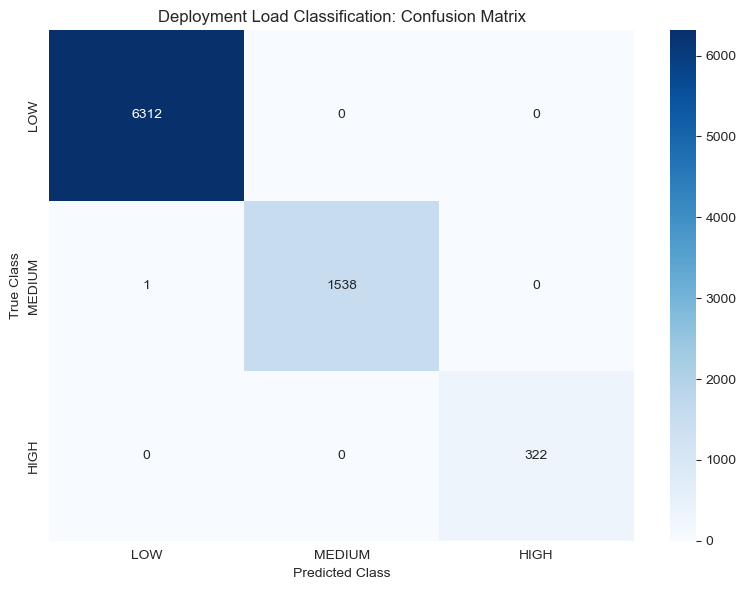

In [5]:
# Generate predictions
df['pred_deployment'] = deployment_model.predict(X)

print('--- Classification Report ---')
print(classification_report(df[DEPLOYMENT_TARGET], df['pred_deployment']))

# Confusion Matrix
cm = confusion_matrix(df[DEPLOYMENT_TARGET], df['pred_deployment'], labels=['LOW', 'MEDIUM', 'HIGH'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['LOW', 'MEDIUM', 'HIGH'], 
            yticklabels=['LOW', 'MEDIUM', 'HIGH'])
plt.title('Deployment Load Classification: Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'deployment_confusion_matrix.png', dpi=150)
plt.show()

## 4. Cross-Model Feature Importance Analysis
Compare feature importances across all three models to see what drivers impact each operation task.

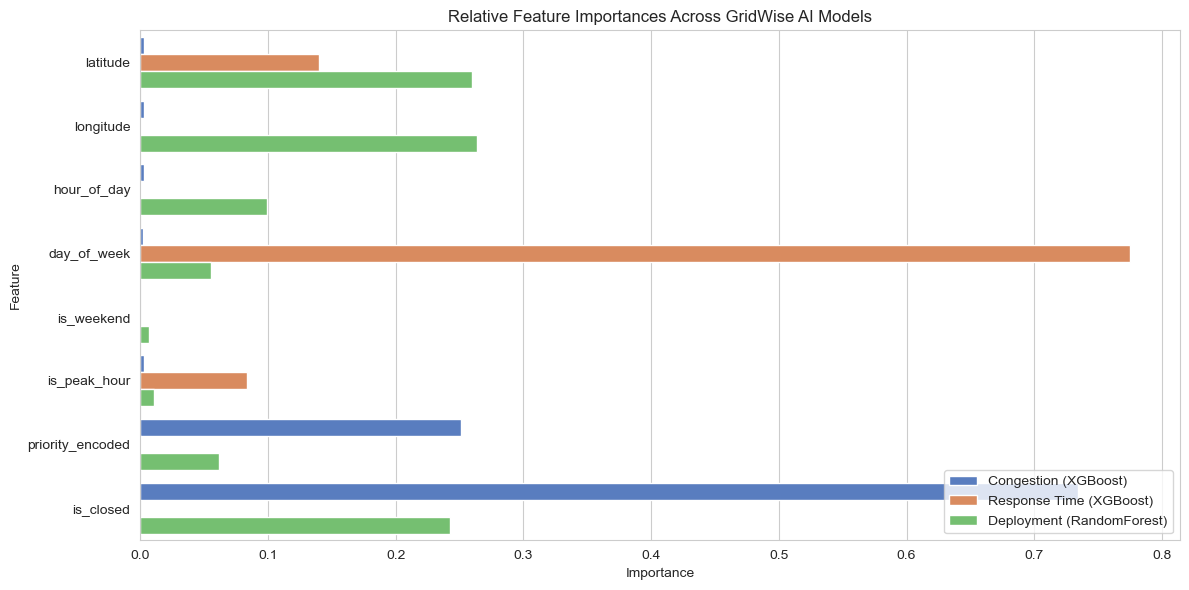

In [6]:
# Compile feature importances
importance_df = pd.DataFrame({
    'Feature': features,
    'Congestion (XGBoost)': congestion_model.feature_importances_,
    'Response Time (XGBoost)': response_model.feature_importances_,
    'Deployment (RandomForest)': deployment_model.feature_importances_
})

importance_melted = importance_df.melt(id_vars='Feature', var_name='Model', value_name='Importance')

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', hue='Model', data=importance_melted, palette='muted')
plt.title('Relative Feature Importances Across GridWise AI Models')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cross_model_feature_importance.png', dpi=150)
plt.show()

## 5. Key Operational Recommendations
1. **Road Closures (`is_closed`)**: Crucial predictor for both congestion and deployment load. Incident managers should instantly tag road closure flags to optimize resource scheduling.
2. **Peak Hours vs Off-Peak**: Model weights confirm significant congestion surges during standard peak hour bands. Scheduled works should be shifted outside these bounds.
3. **Response Estimation**: Real-time response model outputs can be served directly to public map APIs to manage commuter expectations.